In [3]:
import pandas as pd 
import matplotlib.pyplot as plt

df_mortalidad = pd.read_parquet("mortalidad_limpio.parquet")

df_mortalidad = df_mortalidad[df_mortalidad['ANO'] < 2026]

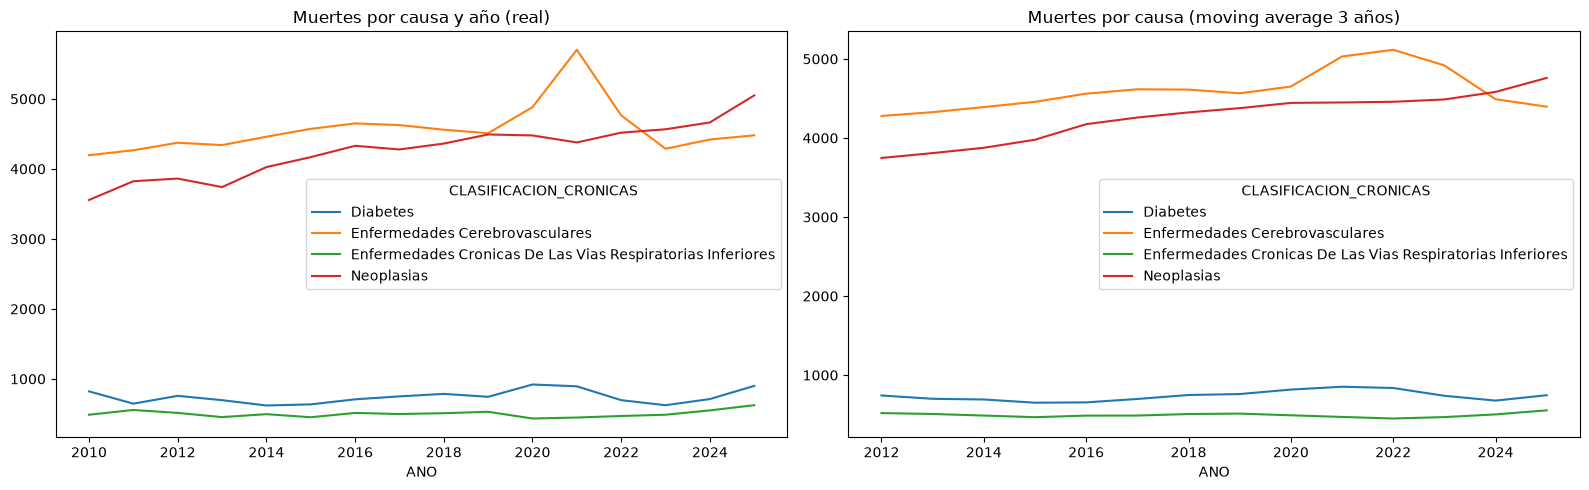

In [4]:
# Cuenta muertes agrupando por año y causa
tendencia = df_mortalidad.groupby(['ANO','CLASIFICACION_CRONICAS']).size().reset_index(name='total')

# Reorganiza: años en filas, cada causa como columna
tabla_tendencia = tendencia.pivot(index='ANO', columns='CLASIFICACION_CRONICAS', values='total')

# Calcula el promedio móvil de 3 años (suaviza picos y ruido año a año)
tabla_ma = tabla_tendencia.rolling(window=3).mean()

# Crea figura con 2 gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grafica los datos reales (una línea por causa)
tabla_tendencia.plot(ax=axes[0], title='Muertes por causa y año (real)')

# Grafica la versión suavizada (una línea por causa)
tabla_ma.plot(ax=axes[1], title='Muertes por causa (moving average 3 años)')

# Ajusta espacios
plt.tight_layout()

# Guarda imagen
plt.savefig('tendencia_causas.png', dpi=150)

# Muestra
plt.show()